1. Initializing system...
Device in use: cpu
2. Loading AI Brain...
Loading weights from: d:\New folder\plant-disease-ai\models\resnet18_phase2_best.pth
3. Running Diagnostic and Grad-CAM...
Selected Image: D:\TTNT\PlantVillage-Dataset\raw\color\Apple___Apple_scab\0a5e9323-dbad-432d-ac58-d291718345d9___FREC_Scab 3417.JPG
Analyzing image: D:\TTNT\PlantVillage-Dataset\raw\color\Apple___Apple_scab\0a5e9323-dbad-432d-ac58-d291718345d9___FREC_Scab 3417.JPG
AI Prediction: Apple___Apple_scab (80.77%)


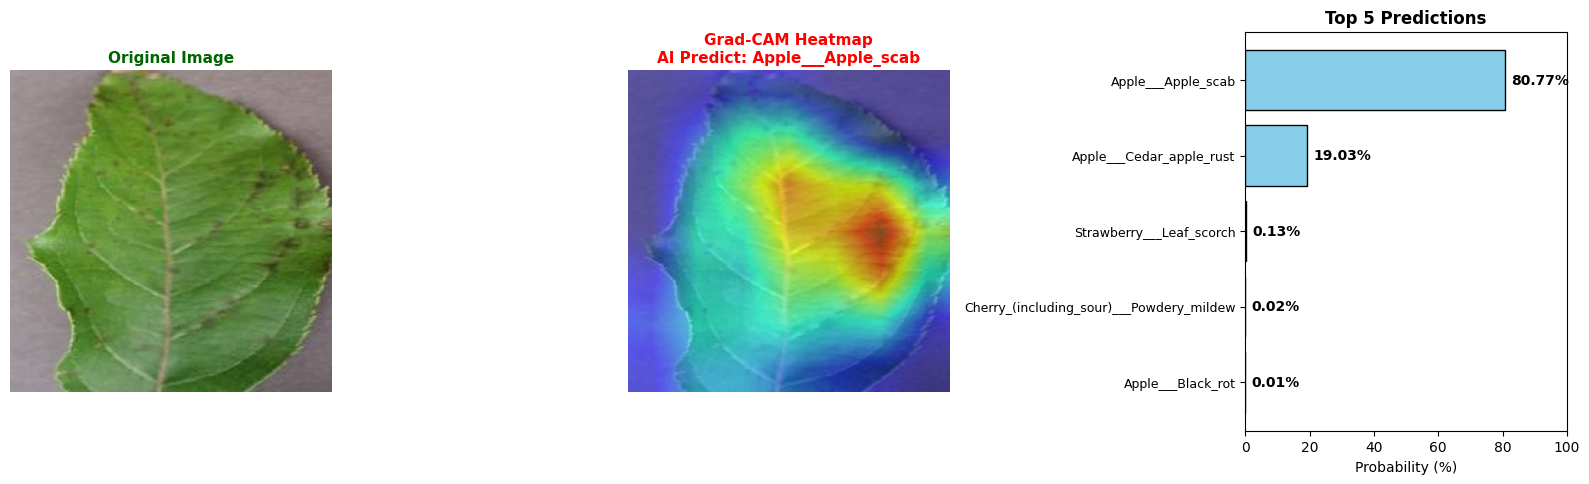


           DISEASE INFORMATION

Tên bệnh: Bệnh vảy đen (Ghẻ táo)
Tên tiếng Anh: Apple Scab
Cây trồng: Táo

Mô tả:
Bệnh vảy đen là một trong những bệnh nấm phổ biến nhất trên cây táo, làm ảnh hưởng nghiêm trọng đến năng suất và tính thẩm mỹ của quả. Nếu không được kiểm soát, cây sẽ rụng lá sớm và quả bị biến dạng.

Triệu chứng:
- Xuất hiện các đốm màu xanh ô liu nhạt, sau đó chuyển sang màu nâu đen trên bề mặt lá.
- Lá có thể bị xoắn lại, co rộp và rụng sớm.
- Trên quả xuất hiện các đốm vảy đen, nứt nẻ và làm quả bị biến dạng hoặc nứt rách.

Nguyên nhân:
- Do nấm Venturia inaequalis gây ra.
- Bào tử nấm lây lan mạnh qua gió và nước mưa.
- Thời tiết mùa xuân mát mẻ và ẩm ướt là điều kiện lý tưởng cho nấm bùng phát.

Phòng ngừa:
- Thu gom và tiêu hủy toàn bộ lá rụng trong vườn để cắt đứt nguồn bệnh qua đông.
- Cắt tỉa cành lá thường xuyên để tán cây thông thoáng, giúp lá nhanh khô sau mưa.
- Lựa chọn các giống táo có khả năng kháng bệnh vảy đen.

Cách điều trị:
- Phun thuốc diệt nấm phòn

In [3]:
import sys
import os
import torch

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(PROJECT_ROOT)

from src.load_model import load_best_model
from src.gradcam import visualize_gradcam
from src.disease_database import get_disease


CUSTOM_IMAGE_PATH = r"D:\TTNT\PlantVillage-Dataset\raw\color\Apple___Apple_scab\0a5e9323-dbad-432d-ac58-d291718345d9___FREC_Scab 3417.JPG"
# ==========================================

print("1. Initializing system...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")

print("2. Loading AI Brain...")
model = load_best_model(device)

print(f"3. Running Diagnostic and Grad-CAM...")
print(f"Selected Image: {CUSTOM_IMAGE_PATH}")

predicted_class = visualize_gradcam(
    model,
    CUSTOM_IMAGE_PATH,
    true_label=None
)

disease = get_disease(predicted_class)

if disease is None:

    print("\nKhông tìm thấy thông tin trong diseases.json")

    print(
        f"Class cần tìm: {predicted_class}"
    )

else:

    print("\n========================================")
    print("           DISEASE INFORMATION")
    print("========================================")

    print(f"\nTên bệnh: {disease['name']}")

    print(
        f"Tên tiếng Anh: "
        f"{disease['english_name']}"
    )

    print(
        f"Cây trồng: "
        f"{disease['crop']}"
    )

    print("\nMô tả:")
    print(disease['description'])

    print("\nTriệu chứng:")

    for symptom in disease['symptoms']:
        print(f"- {symptom}")

    print("\nNguyên nhân:")

    for cause in disease['cause']:
        print(f"- {cause}")

    print("\nPhòng ngừa:")

    for item in disease['prevention']:
        print(f"- {item}")

    print("\nCách điều trị:")

    for item in disease['treatment']:
        print(f"- {item}")

print("Custom Demo completed successfully!")